# Semi-discrete Laguerre Cells

This notebook generates `fig:semidiscrete-laguerre-cells`.  For the quadratic cost and a discrete target
$$
    \beta=\sum_{j=1}^m b_j\delta_{y_j},
$$
the semi-dual weights $\gamma_j$ define Laguerre cells
$$
    L_j(\gamma)=\{x:\ \|x-y_j\|^2-\gamma_j\leq \|x-y_k\|^2-\gamma_k\ \text{for all }k\}.
$$
The figure shows how changing the weights deforms the ordinary Voronoi diagram until the continuous density assigns the prescribed mass to each target atom.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linprog
from scipy.spatial import Delaunay

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY, BACKGROUND,
    DIRAC_MARKER_SIZE, MASS_MARKER_MIN_FACTOR, MASS_MARKER_MAX_FACTOR,
    TRANSPORT_LINE_MIN_WIDTH, POINT_EDGE_WIDTH,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, padded_limits,
    interp_color,
)

setup_matplotlib()

NAME = "semidiscrete-laguerre-cells"
OUT = figure_dir(NAME)


## Shared geometry

The continuous density is a three-component Gaussian mixture located on the right.  The twenty-one target atoms are sampled from a compact Gaussian cloud on the left.  This deliberately asymmetric setup makes the Laguerre correction visible: the final cells stretch across the density rather than simply clustering around the target atoms.

In [2]:
rng = np.random.default_rng(612)

xlim = (-2.15, 2.25)
ylim = (-1.75, 1.75)
gx = np.linspace(*xlim, 205)
gy = np.linspace(*ylim, 170)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX, GY], axis=-1)
flat = grid.reshape(-1, 2)

means = np.array([
    [0.38, 0.22],
    [1.17, 0.70],
    [1.05, -0.72],
])
covs = np.array([
    [[0.33, 0.08], [0.08, 0.24]],
    [[0.22, -0.06], [-0.06, 0.16]],
    [[0.18, 0.02], [0.02, 0.13]],
])
weights = np.array([0.50, 0.31, 0.19])


def gaussian_2d(xx, yy, mean, cov):
    diff = np.stack([xx - mean[0], yy - mean[1]], axis=-1)
    inv = np.linalg.inv(cov)
    quad = np.einsum("...i,ij,...j->...", diff, inv, diff)
    return np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

rho = sum(w * gaussian_2d(GX, GY, mu, cov) for w, mu, cov in zip(weights, means, covs))
rho = rho / rho.sum()

m = 21
sites = rng.multivariate_normal(mean=[-0.92, -0.05], cov=[[0.16, 0.035], [0.035, 0.34]], size=m)
sites[:, 0] = np.clip(sites[:, 0], xlim[0] + 0.30, -0.15)
sites[:, 1] = np.clip(sites[:, 1], ylim[0] + 0.24, ylim[1] - 0.24)
# Order sites from bottom to top so colors are spatially coherent.
sites = sites[np.argsort(sites[:, 1] + 0.25 * sites[:, 0])]

palette = []
for t in np.linspace(0.0, 1.0, m):
    if t < 0.52:
        palette.append(interp_color(t / 0.52, BLUE, VIOLET))
    else:
        palette.append(interp_color((t - 0.52) / 0.48, VIOLET, ORANGE))
cell_cmap = ListedColormap(palette)

C_grid = ((grid[..., None, 0] - sites[:, 0]) ** 2 + (grid[..., None, 1] - sites[:, 1]) ** 2)
C_flat_sites = ((flat[:, None, 0] - sites[:, 0]) ** 2 + (flat[:, None, 1] - sites[:, 1]) ** 2)


def draw_density_contours(ax):
    levels = np.quantile(rho[rho > 0], [0.68, 0.78, 0.86, 0.92, 0.96, 0.985])
    ax.contour(GX, GY, rho, levels=levels, colors=[RED], linewidths=0.58, alpha=0.40, zorder=3)


def finish_geometry(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)

beta = np.full(m, 1.0 / m)


## Weight updates

We use a lightweight semi-dual gradient ascent on the discretized density.  The update direction is
$$
    \nabla \mathcal E(\gamma)_j=b_j-\alpha(L_j(\gamma)),
$$
so a cell with too little density mass receives a larger weight and expands.

In [3]:

def laguerre_labels(gamma):
    return np.argmin(C_grid - gamma[None, None, :], axis=2)

snapshots = {}
gamma = np.zeros(m)
for it in range(128 + 1):
    labels = laguerre_labels(gamma)
    masses = np.array([(rho * (labels == j)).sum() for j in range(m)])
    if it in {0, 20, 128}:
        snapshots[it] = (labels.copy(), masses.copy(), gamma.copy())
    step = 2.45 / np.sqrt(it + 4.0)
    gamma += step * (beta - masses)
    gamma -= gamma.mean()

final_error = np.linalg.norm(snapshots[128][1] - beta, ord=1)
final_error


np.float64(0.03199022346398456)

## Exported panels

Cells and their target atoms share the same color.  The red contours show the continuous density; the circles are intentionally small and unoutlined.

In [4]:

files = {0: "voronoi.pdf", 20: "weighted.pdf", 128: "balanced.pdf"}
for it, filename in files.items():
    labels, masses, gamma_snapshot = snapshots[it]
    fig, ax = plt.subplots(figsize=(2.35, 2.02))
    ax.pcolormesh(GX, GY, labels, cmap=cell_cmap, shading="nearest", alpha=0.26, rasterized=True, zorder=1)
    ax.contour(GX, GY, labels, levels=np.arange(m + 1) - 0.5, colors="white", linewidths=0.48, alpha=0.82, zorder=2)
    draw_density_contours(ax)
    ax.scatter(sites[:, 0], sites[:, 1], s=DIRAC_MARKER_SIZE * 0.64, marker="o", c=palette, edgecolor="none", linewidth=0, zorder=5)
    finish_geometry(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.052)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


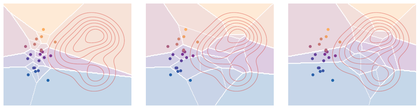

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/semidiscrete-laguerre-cells.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/semidiscrete-laguerre-cells.png")
display(Image(filename=str(_thumb)))
